# From Pandas to Dask

This notebook introduces Pandas for structured data analysis and then shows how Dask scales the same API to multiple files and larger-than-memory datasets.

In [1]:
import psutil
import pathlib
import numpy as np
import pandas as pd
import dask.dataframe as dd
import matplotlib.pyplot as plt
%matplotlib inline

print(f"Available RAM: {psutil.virtual_memory().available / (1024 ** 3):.1f} GB")

Available RAM: 8.5 GB


## Part 1: Pandas Basics with Simulated Data

We simulate a physics experiment: measuring distance and time with Gaussian uncertainty, then compute derived quantities using vectorized operations.

In [2]:
n_samples = 1_000
distance_samples_m = np.random.normal(loc=100, scale=10, size=n_samples)
time_samples_s = np.random.normal(loc=10, scale=2, size=n_samples)

df = pd.DataFrame({"distance_m": distance_samples_m, "time_s": time_samples_s})
df.head()

,distance_m,time_s
0,100.651136,8.681370
1,86.040405,8.692105
2,98.071597,11.904237
3,102.018448,9.809404
4,81.230815,7.723931


<Axes: xlabel='time [s]', ylabel='distance [m]'>

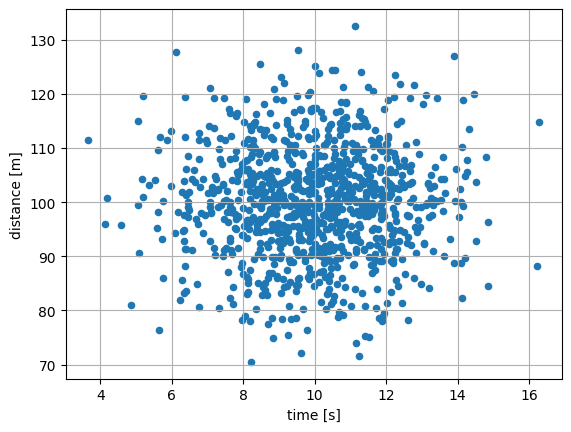

In [3]:
df.plot.scatter("time_s", "distance_m", xlabel="time [s]", ylabel="distance [m]", grid=True)

### Vectorized Operations

Pandas applies operations to entire columns at C speed — no Python loops needed:

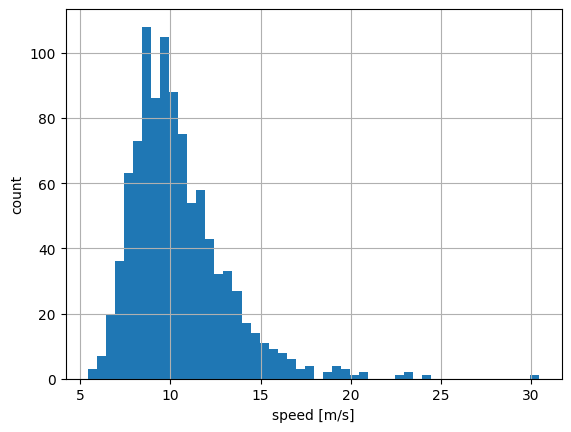

In [4]:
df["speed_m_per_s"] = df.distance_m / df.time_s
df.speed_m_per_s.hist(bins=50)
plt.xlabel("speed [m/s]")
plt.ylabel("count");

## Part 2: Real-World Data — Weather Station

We download meteorological data from a Polish weather archive and process it first with Pandas, then with Dask.

In [5]:
# Weather data download (with pre-staged fallback for shared environments)
import shutil, requests, re

data_dir = pathlib.Path("meteo")
shared_meteo = pathlib.Path("/net/pr2/projects/tutorial/2025-09-25-hpda/meteo")

if shared_meteo.exists() and any(shared_meteo.glob("*.txt")):
    # Copy pre-staged data (fast, no network dependency)
    if not data_dir.exists():
        shutil.copytree(shared_meteo, data_dir)
        print(f"Copied pre-staged data from {shared_meteo}")
    else:
        print(f"Data directory already exists: {data_dir}")
else:
    # Download from web (fallback)
    data_dir.mkdir(exist_ok=True)
    base = "https://meteo.gig.eu/archiwum/2025/"
    html = requests.get(base).text
    files = re.findall(r'href="([^"]+\.\w+)"'  , html)
    for f in files:
        url = f if f.startswith("http") else base + f
        name = pathlib.Path(url).name
        print("Downloading", name)
        with requests.get(url, stream=True) as r, open(data_dir / name, "wb") as out:
            for chunk in r.iter_content(1024 * 64):
                out.write(chunk)

### Data Schema

The weather station records 36 variables: temperature, humidity, wind, pressure, solar radiation, etc.

In [6]:
columns = [
    "Date", "Time", "TempOut", "TempHi", "TempLow", "HumOut", "DewPt",
    "WindSpeed", "WindDir", "WindRun", "WindSpeedHi", "WindDirHi", "WindChill",
    "HeatIndex", "THWIndex", "THSWIndex", "Bar", "Rain", "RainRate",
    "SolarRad", "SolarEnergy", "SolarRadHi", "UVIndex", "UVDose", "UVIndexHi",
    "HeatDD", "CoolDD", "TempIn", "HumIn", "DewPtIn", "HeatIn", "ET",
    "WindSamp", "WindTx", "ISSRecept", "ArcInt"
]

### Pandas: Single File

In [7]:
first_file = next(data_dir.glob("*.txt"))
df_single = pd.read_csv(first_file, sep=r'\s+', names=columns, skiprows=3, na_values=["---", "------"])
df_single.head()

,Date,Time,TempOut,TempHi,TempLow,HumOut,DewPt,WindSpeed,WindDir,WindRun,...,CoolDD,TempIn,HumIn,DewPtIn,HeatIn,ET,WindSamp,WindTx,ISSRecept,ArcInt
0,25-09-14,0:30,16.9,17.1,16.7,99,16.8,0.4,N,0.80,...,0.0,24.4,46,12.1,24.2,0.0,697,1,100.0,30
1,25-09-14,1:00,16.8,16.8,16.7,99,16.6,0.4,N,0.80,...,0.0,24.4,46,12.0,24.1,0.0,701,1,100.0,30
2,25-09-14,1:30,16.9,16.9,16.8,97,16.4,0.4,N,0.80,...,0.0,24.4,46,12.0,24.1,0.0,700,1,100.0,30
3,25-09-14,2:00,16.7,16.9,16.6,98,16.4,0.9,N,1.61,...,0.0,24.3,46,12.0,24.1,0.0,699,1,100.0,30
4,25-09-14,2:30,16.7,16.7,16.6,98,16.3,0.4,N,0.80,...,0.0,24.3,46,11.9,24.0,0.0,702,1,100.0,30


<Axes: title={'center': 'Single file'}, xlabel='TempOut', ylabel='HumOut'>

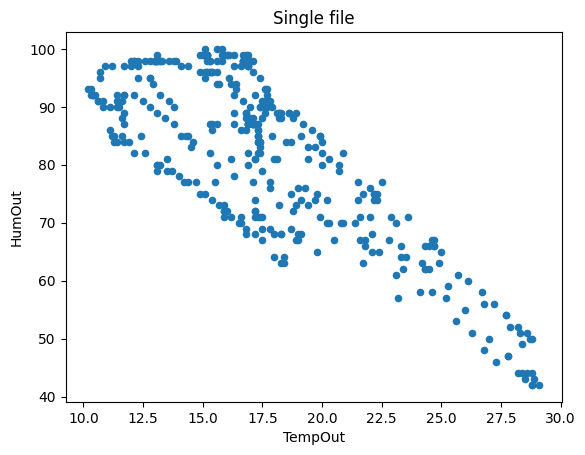

In [8]:
df_single.plot.scatter(x="TempOut", y="HumOut", title="Single file")

### Pandas: All Files (traditional loop + concat)

The sequential approach: load each file, collect DataFrames, concatenate. This requires all data in memory at once.

In [9]:
%%time
df_list = []
for file_path in data_dir.glob("*.txt"):
    df_tmp = pd.read_csv(file_path, sep=r'\s+', names=columns, skiprows=3, na_values=["---", "------"])
    df_list.append(df_tmp)
df_all = pd.concat(df_list)
print(f"Total rows: {len(df_all):,}")

Total rows: 19,891
CPU times: user 83.1 ms, sys: 12 ms, total: 95.1 ms
Wall time: 101 ms


### Dask: All Files in One Line

Dask reads all files with a glob pattern and creates a lazy DataFrame. No data is loaded until  is called.

In [10]:
df_dask = dd.read_csv(
    data_dir / "*.txt", sep=r'\s+', names=columns, skiprows=3,
    na_values=["---", "------"], assume_missing=True
)

# Fix integer columns that may have NaN
for col in ["HumIn", "HumOut", "SolarRad", "SolarRadHi"]:
    df_dask[col] = df_dask[col].fillna(-1).astype("int64")

In [11]:
# This is lazy — just metadata, no data loaded yet
df_dask

,Date,Time,TempOut,TempHi,TempLow,HumOut,DewPt,WindSpeed,WindDir,WindRun,WindSpeedHi,WindDirHi,WindChill,HeatIndex,THWIndex,THSWIndex,Bar,Rain,RainRate,SolarRad,SolarEnergy,SolarRadHi,UVIndex,UVDose,UVIndexHi,HeatDD,CoolDD,TempIn,HumIn,DewPtIn,HeatIn,ET,WindSamp,WindTx,ISSRecept,ArcInt
npartitions=52,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
,string,string,float64,float64,float64,int64,float64,float64,string,float64,float64,string,float64,float64,float64,float64,float64,float64,float64,int64,float64,int64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...


### Triggering Computation

 executes the entire task graph and returns a Pandas DataFrame. Use it only when you need the final result.

In [12]:
# Compute a single statistic (minimal data transfer)
df_dask.TempOut.mean().compute()

np.float64(11.131679235796884)

<Axes: title={'center': 'All files via Dask'}, xlabel='TempOut', ylabel='HumOut'>

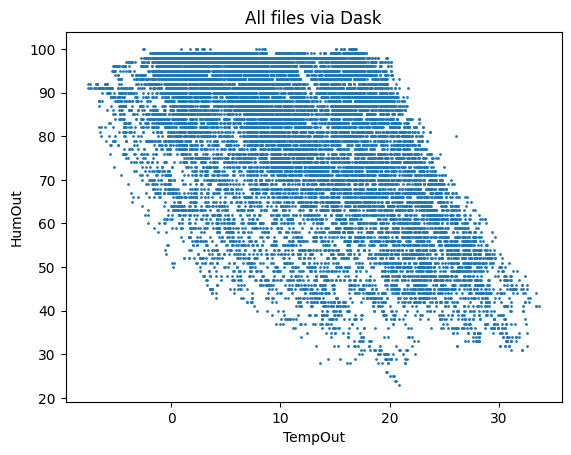

In [13]:
# Materialize full DataFrame for plotting (all data in memory)
df_dask.compute().plot.scatter(x="TempOut", y="HumOut", s=1, title="All files via Dask")

### Saving to HDF5

Binary formats like HDF5 are much faster to read/write than CSV and support compression.

In [14]:
h5_path = data_dir / "meteo_dask.h5"
df_dask.to_hdf(h5_path, key="df", mode="w")
print(f"Uncompressed: {h5_path.stat().st_size / (1024**2):.1f} MB")

df_dask.to_hdf(h5_path, key="df", mode="w", complevel=5)
print(f"Compressed:   {h5_path.stat().st_size / (1024**2):.1f} MB")

Uncompressed: 5.5 MB
Compressed:   1.0 MB


## Exercise 1

**Compute the mean wind speed** using both Pandas () and Dask (). Verify the results match.

In [ ]:
# Exercise 1: compute mean WindSpeed with both Pandas and Dask

pandas_mean = ___  # YOUR CODE: df_all.WindSpeed...
dask_mean = ___    # YOUR CODE: df_dask.WindSpeed...

print(f"Pandas mean wind speed: {pandas_mean:.4f}")
print(f"Dask mean wind speed:   {dask_mean:.4f}")

## Exercise 2

**Scale the physics simulation to 100 million samples.** Regenerate the distance/time DataFrame. What happens to the speed histogram shape? Does it still look Gaussian?

In [ ]:
# Exercise 2: scale to 100M samples

n_samples_large = 100_000_000

# YOUR CODE HERE: create df_large with distance_m and time_s columns
# Then compute speed and plot the histogram with bins=200